In [4]:
import os
import psutil

ram = psutil.virtual_memory()
print(f"Total RAM:     {ram.total / 1e9:.1f} GB")
print(f"Available RAM: {ram.available / 1e9:.1f} GB")
print(f"Used:          {ram.percent}%")

Total RAM:     17.1 GB
Available RAM: 5.9 GB
Used:          65.5%


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All packages imported successfully!")

All packages imported successfully!


In [5]:
# Only the columns we need
# cols = [
#     # Identifiers
#     'game_id', 'play_id', 'game_date', 'week', 'season',
#     'home_team', 'away_team', 'posteam', 'defteam',

#     # Game state (model inputs)
#     'down', 'ydstogo', 'yardline_100',
#     'score_differential', 'qtr', 'game_seconds_remaining',
#     'posteam_timeouts_remaining', 'defteam_timeouts_remaining',
#     'shotgun', 'no_huddle',

#     # Formation & personnel
#     'offense_formation',       # SHOTGUN, SINGLEBACK, EMPTY, etc.
#     'offense_personnel',       # "1 RB, 1 TE, 3 WR" etc.
#     'defenders_in_box',        # how many defenders stacked vs run

#     # Play outcome (what we train on)
#     'play_type',               # run / pass / etc.
#     'success',                 # did the play succeed? (our key target)
#     'epa',                     # expected points added per play
#     'wpa',                     # win probability added
#     'yards_gained',

#     # Pass-specific outcomes
#     'air_yards',               # how far the ball traveled in the air
#     'yac',                     # yards after catch
#     'yac_success',

#     # Run-specific outcomes
#     'run_gap',                 # where the run went (left/right/middle)
#     'run_location',

#     # Context
#     'wp',                      # win probability before play
#     'ep',                      # expected points before play
#     'goal_to_go',              # red zone situation
#     'roof', 'surface',         # environment
# ]

# Load each file
data_folder= r'C:\Users\ajguz\aic\data'

df_2023 = pd.read_csv(os.path.join(data_folder,'play_by_play_2023.csv.gz'), compression='gzip', low_memory=False,)
print("2023 season")
print(f"\nDone! Total plays loaded: {len(df_2023):,}")
print(f"Columns: {len(df_2023.columns)}")

df_2024 = pd.read_csv(os.path.join(data_folder,'play_by_play_2024.csv.gz'), compression='gzip', low_memory=False,)
print("2024 season")
print(f"\nDone! Total plays loaded: {len(df_2024):,}")
print(f"Columns: {len(df_2024.columns)}")

df_2025 = pd.read_csv(os.path.join(data_folder,'play_by_play_2025.csv.gz'), compression='gzip', low_memory=False,)
print("2025 season")
print(f"\nDone! Total plays loaded: {len(df_2025):,}")
print(f"Columns: {len(df_2025.columns)}")


# Combine into one dataframe
pbp = pd.concat([df_2023, df_2024, df_2025], ignore_index=True)

print(f"\nDone! Total plays loaded: {len(pbp):,}")
print(f"Columns: {len(pbp.columns)}")

column_list = list(pbp.columns)
print(f"columns: {column_list}")


2023 season

Done! Total plays loaded: 49,665
Columns: 372
2024 season

Done! Total plays loaded: 49,492
Columns: 372
2025 season

Done! Total plays loaded: 48,771
Columns: 372

Done! Total plays loaded: 147,928
Columns: 372
columns: ['play_id', 'game_id', 'old_game_id', 'home_team', 'away_team', 'season_type', 'week', 'posteam', 'posteam_type', 'defteam', 'side_of_field', 'yardline_100', 'game_date', 'quarter_seconds_remaining', 'half_seconds_remaining', 'game_seconds_remaining', 'game_half', 'quarter_end', 'drive', 'sp', 'qtr', 'down', 'goal_to_go', 'time', 'yrdln', 'ydstogo', 'ydsnet', 'desc', 'play_type', 'yards_gained', 'shotgun', 'no_huddle', 'qb_dropback', 'qb_kneel', 'qb_spike', 'qb_scramble', 'pass_length', 'pass_location', 'air_yards', 'yards_after_catch', 'run_location', 'run_gap', 'field_goal_result', 'kick_distance', 'extra_point_result', 'two_point_conv_result', 'home_timeouts_remaining', 'away_timeouts_remaining', 'timeout', 'timeout_team', 'td_team', 'td_player_name', '

all cols: 

not found: ['offense_formation', 'yac_success', 'defenders_in_box', 'yac', 'offense_personnel']

In [11]:
# See every column name and its data type
print(pbp.dtypes.to_string())

play_id                                   int64
game_id                                     str
old_game_id                               int64
home_team                                   str
away_team                                   str
season_type                                 str
week                                      int64
posteam                                     str
posteam_type                                str
defteam                                     str
side_of_field                               str
yardline_100                            float64
game_date                                   str
quarter_seconds_remaining               float64
half_seconds_remaining                  float64
game_seconds_remaining                  float64
game_half                                   str
quarter_end                               int64
drive                                   float64
sp                                        int64
qtr                                     

In [19]:
# See how many non-null values each column has
# Columns with mostly nulls might not be useful
print(pbp.isnull().sum().sort_values(ascending=False).to_string())

end_yard_line                           147928
st_play_type                            147928
tackle_with_assist_2_team               147928
tackle_with_assist_2_player_id          147928
tackle_with_assist_2_player_name        147928
lateral_sack_player_name                147928
lateral_sack_player_id                  147928
lateral_punt_returner_player_name       147928
tackle_for_loss_2_player_name           147928
lateral_punt_returner_player_id         147928
tackle_for_loss_2_player_id             147928
lateral_interception_player_id          147925
lateral_interception_player_name        147925
assist_tackle_3_player_name             147924
assist_tackle_4_player_id               147924
assist_tackle_4_player_name             147924
assist_tackle_3_team                    147924
assist_tackle_3_player_id               147924
lateral_kickoff_returner_player_id      147924
lateral_kickoff_returner_player_name    147924
assist_tackle_4_team                    147924
lateral_rushe

In [17]:
pbp.sample(1).T   # .T flips it so columns show as rows - easier to read


,144750
play_id,2145
game_id,2025_18_MIA_NE
old_game_id,2026010410
home_team,NE
away_team,MIA
...,...
xyac_median_yardage,8.0
xyac_success,0.251697
xyac_fd,0.082937
xpass,0.964489


end_yard_line                        100.0
st_play_type                         100.0
tackle_with_assist_2_team            100.0
tackle_with_assist_2_player_id       100.0
tackle_with_assist_2_player_name     100.0
lateral_sack_player_name             100.0
lateral_sack_player_id               100.0
lateral_punt_returner_player_name    100.0
tackle_for_loss_2_player_name        100.0
lateral_punt_returner_player_id      100.0
tackle_for_loss_2_player_id          100.0
dtype: float64
Always empty  (100% null):         11 columns  ← drop these
Mostly empty  (50–99% null):       133 columns  ← drop most
Sometimes null (1–49% null):       132 columns  ← review these
Always filled (0% null):           96 columns  ← keep these


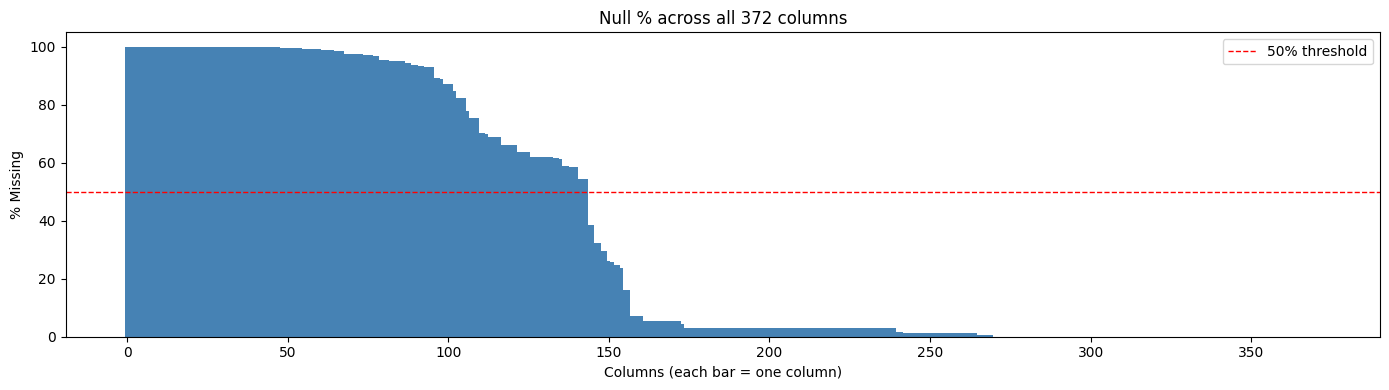

In [ ]:
# Calculate null percentage for every column
null_pct = (pbp.isnull().sum() / len(pbp) * 100).sort_values(ascending=False)

# Bucket columns into 4 groups
always_null    = null_pct[null_pct == 100]
print(always_null)
mostly_null    = null_pct[(null_pct >= 50) & (null_pct < 100)]
sometimes_null = null_pct[(null_pct > 0) & (null_pct < 50)]
always_filled  = null_pct[null_pct == 0]

print(f"Always empty  (100% null):         {len(always_null)} columns  ← drop these")
print(f"Mostly empty  (50–99% null):       {len(mostly_null)} columns  ← drop most")
print(f"Sometimes null (1–49% null):       {len(sometimes_null)} columns  ← review these")
print(f"Always filled (0% null):           {len(always_filled)} columns  ← keep these")

# Visual bar chart of null % across all columns
plt.figure(figsize=(14, 4))
plt.bar(range(len(null_pct)), null_pct.values, color='steelblue', width=1.0)
plt.axhline(y=50, color='red', linestyle='--', linewidth=1, label='50% threshold')
plt.xlabel('Columns (each bar = one column)')
plt.ylabel('% Missing')
plt.title('Null % across all 372 columns')
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
# Drop any column that is more than 95% empty
threshold = 95
cols_to_drop = null_pct[null_pct >= threshold].index.tolist()

print(f"Dropping {len(cols_to_drop)} columns that are {threshold}%+ null...")


Dropping 87 columns that are 95%+ null...


In [24]:
# Drop any column that is more than 95% empty
threshold = 95
cols_to_drop = null_pct[null_pct >= threshold].index.tolist()

print(f"Dropping {len(cols_to_drop)} columns that are {threshold}%+ null...")
pbp_clean = pbp.drop(columns=cols_to_drop)

print(f"Columns remaining: {len(pbp_clean.columns)}")
print(f"Memory usage: {pbp_clean.memory_usage(deep=True).sum() / 1e9:.2f} GB")

Dropping 87 columns that are 95%+ null...
Columns remaining: 285
Memory usage: 0.84 GB


In [26]:
# Group columns by category so we can understand what we have
column_groups = {
    'Game identifiers': [
        'game_id', 'play_id', 'old_game_id', 'game_date', 'week', 
        'season', 'season_type', 'game_half'
    ],
    'Teams': [
        'home_team', 'away_team', 'posteam', 'defteam', 
        'posteam_type', 'side_of_field'
    ],
    'Game state (model inputs)': [
        'down', 'ydstogo', 'yardline_100', 'qtr',
        'game_seconds_remaining', 'half_seconds_remaining',
        'quarter_seconds_remaining', 'score_differential',
        'posteam_score', 'defteam_score',
        'posteam_timeouts_remaining', 'defteam_timeouts_remaining',
        'goal_to_go', 'shotgun', 'no_huddle', 'wp', 'ep'
    ],
    'Formation & personnel': [
        'offense_formation', 'offense_personnel', 'defenders_in_box',
        'defense_personnel', 'number_of_pass_rushers',
        'n_offense', 'n_defense'
    ],
    'Play outcome (target variables)': [
        'play_type', 'play_type_nfl', 'success', 'epa', 'wpa',
        'yards_gained', 'air_yards', 'yac', 'yac_success',
        'run_location', 'run_gap', 'pass_location', 'pass_length'
    ],
    'Passer info': [
        'passer_player_id', 'passer_player_name',
        'qb_hit', 'qb_scramble', 'qb_dropback',
        'sack', 'complete_pass', 'incomplete_pass',
        'interception', 'touchdown'
    ],
    'Rusher info': [
        'rusher_player_id', 'rusher_player_name', 'rushing_yards'
    ],
    'Receiver info': [
        'receiver_player_id', 'receiver_player_name',
        'receiving_yards', 'yards_after_catch'
    ],
    'Blocking & defense': [
        'tackled_for_loss', 'tackle_with_assist',
        'solo_tackle', 'assist_tackle',
        'fumble', 'fumble_lost', 'penalty'
    ],
    'Advanced metrics': [
        'xyac_epa', 'xyac_success', 'xyac_mean_yardage',
        'xpass', 'pass_oe',                   
        'cp', 'cpoe',                          
        'ep', 'epa', 'wp', 'wpa',
        'vegas_wp', 'vegas_wpa',
        'comp_air_epa', 'comp_yac_epa'
    ],
    'Environment': [
        'roof', 'surface', 'temp', 'wind',
        'stadium', 'stadium_id', 'location'
    ],
    'Special teams': [
        'field_goal_result', 'kick_distance',
        'punt_blocked', 'return_yards'
    ],
}

# Print which of these columns actually exist in your dataframe
print("=" * 55)
print(f"{'CATEGORY':<30} {'FOUND':>6} {'MISSING':>8}")
print("=" * 55)

all_found = []
for group, cols in column_groups.items():
    found    = [c for c in cols if c in pbp_clean.columns]
    missing  = [c for c in cols if c not in pbp_clean.columns]
    all_found.extend(found)
    print(f"{group:<30} {len(found):>6} / {len(cols):<3}  ", end="")
    if missing:
        print(f"missing: {missing}")
    else:
        print("✓ all present")

# Columns we haven't categorized yet
uncategorized = [c for c in pbp_clean.columns if c not in all_found]
print(f"\nUncategorized columns: {len(uncategorized)}")
print(uncategorized)

CATEGORY                        FOUND  MISSING
Game identifiers                    8 / 8    ✓ all present
Teams                               6 / 6    ✓ all present
Game state (model inputs)          17 / 17   ✓ all present
Formation & personnel               0 / 7    missing: ['offense_formation', 'offense_personnel', 'defenders_in_box', 'defense_personnel', 'number_of_pass_rushers', 'n_offense', 'n_defense']
Play outcome (target variables)     11 / 13   missing: ['yac', 'yac_success']
Passer info                        10 / 10   ✓ all present
Rusher info                         3 / 3    ✓ all present
Receiver info                       4 / 4    ✓ all present
Blocking & defense                  7 / 7    ✓ all present
Advanced metrics                   15 / 15   ✓ all present
Environment                         7 / 7    ✓ all present
Special teams                       3 / 4    missing: ['field_goal_result']

Uncategorized columns: 198
['quarter_end', 'drive', 'sp', 'time', 'yrdln', 'y

In [28]:
# Categorizing all 198 uncategorized columns by purpose
uncategorized_groups = {

    'Drive context': [
        'drive', 'fixed_drive', 'fixed_drive_result',
        'series', 'series_success', 'series_result',
        'drive_play_count', 'drive_time_of_possession',
        'drive_first_downs', 'drive_inside20',
        'drive_ended_with_score', 'drive_yards_penalized',
        'drive_start_yard_line', 'drive_end_yard_line',
        'drive_start_transition', 'drive_end_transition',
    ],

    'Scoring probabilities': [
        'no_score_prob', 'opp_fg_prob', 'opp_safety_prob',
        'opp_td_prob', 'fg_prob', 'safety_prob', 'td_prob',
        'extra_point_prob', 'two_point_conversion_prob',
    ],

    'Cumulative EPA by team (game flow context)': [
        'total_home_epa', 'total_away_epa',
        'total_home_rush_epa', 'total_away_rush_epa',
        'total_home_pass_epa', 'total_away_pass_epa',
        'air_epa', 'yac_epa',
        'qb_epa',
    ],

    'Win probability variants': [
        'def_wp', 'home_wp', 'away_wp',
        'home_wp_post', 'away_wp_post',
        'vegas_home_wp', 'vegas_home_wpa',
    ],

    'Down conversion outcomes': [
        'first_down', 'first_down_rush', 'first_down_pass',
        'first_down_penalty', 'third_down_converted',
        'third_down_failed', 'fourth_down_converted',
        'fourth_down_failed',
    ],

    'Play type flags (binary yes/no columns)': [
        'rush_attempt', 'pass_attempt', 'qb_dropback',
        'qb_scramble', 'qb_kneel', 'qb_spike',
        'pass_touchdown', 'rush_touchdown',
        'extra_point_attempt', 'two_point_attempt',
        'field_goal_attempt', 'punt_attempt',
        'kickoff_attempt', 'special_teams_play',
    ],

    'Player name/id shortcuts (duplicates of other cols)': [
        'passer', 'passer_id', 'passer_jersey_number',
        'rusher', 'rusher_id', 'rusher_jersey_number',
        'receiver', 'receiver_id', 'receiver_jersey_number',
        'name', 'jersey_number', 'id',
        'fantasy_player_name', 'fantasy_player_id',
        'fantasy', 'fantasy_id',
    ],

    'Penalty info': [
        'penalty_team', 'penalty_player_id',
        'penalty_player_name', 'penalty_yards',
        'penalty_type', 'replay_or_challenge',
    ],

    'Score & game result': [
        'home_score', 'away_score', 'result', 'total',
        'total_home_score', 'total_away_score',
        'posteam_score_post', 'defteam_score_post',
        'score_differential_post',
        'spread_line', 'total_line',
    ],

    'Game/stadium metadata': [
        'home_coach', 'away_coach', 'game_stadium',
        'div_game', 'nfl_api_id', 'start_time',
        'time_of_day', 'weather', 'play_clock',
        'home_opening_kickoff',
    ],

    'Expected YAC advanced metrics': [
        'xyac_epa', 'xyac_success', 'xyac_mean_yardage',
        'xyac_median_yardage', 'xyac_fd',
    ],

    'Probably drop (noise / edge cases)': [
        'lateral_reception', 'lateral_rush', 'lateral_return',
        'lateral_recovery', 'aborted_play', 'play_deleted',
        'touchback', 'safety', 'own_kickoff_recovery',
        'own_kickoff_recovery_td', 'out_of_bounds',
        'punt_inside_twenty', 'punt_in_endzone',
        'punt_out_of_bounds', 'punt_downed', 'punt_fair_catch',
        'kickoff_inside_twenty', 'kickoff_in_endzone',
        'kickoff_out_of_bounds', 'kickoff_downed',
        'kickoff_fair_catch',
    ],
}

print("=" * 60)
print(f"{'CATEGORY':<45} {'COUNT':>5}")
print("=" * 60)
for group, cols in uncategorized_groups.items():
    found = [c for c in cols if c in pbp_clean.columns]
    print(f"{group:<45} {len(found):>5} cols")

CATEGORY                                      COUNT
Drive context                                    16 cols
Scoring probabilities                             9 cols
Cumulative EPA by team (game flow context)        9 cols
Win probability variants                          7 cols
Down conversion outcomes                          8 cols
Play type flags (binary yes/no columns)          14 cols
Player name/id shortcuts (duplicates of other cols)    16 cols
Penalty info                                      6 cols
Score & game result                              11 cols
Game/stadium metadata                            10 cols
Expected YAC advanced metrics                     5 cols
Probably drop (noise / edge cases)               21 cols


In [29]:
# Columns to drop - just reference the groups you defined earlier
cols_to_drop = (uncategorized_groups['Probably drop (noise / edge cases)'])

# Only drop columns that actually exist (safety check)
cols_to_drop = [c for c in cols_to_drop if c in pbp_clean.columns]

pbp_clean = pbp_clean.drop(columns=cols_to_drop)

print(f"Dropped {len(cols_to_drop)} columns")
print(f"Columns remaining: {len(pbp_clean.columns)}")

Dropped 21 columns
Columns remaining: 264
